- OFT&TST对齐的细胞的 pre post rescue的频率，频率是500ms（5帧）为间隔，存在激活细胞峰值，暂定为1.5倍std
- OFT&TST对齐的细胞的 pre post rescue的最大峰值
- OFT&TST对齐的细胞的 pre post rescue的神经活动的tracing heatmap

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re 
from scipy.cluster import hierarchy
from scipy import cluster   
from scipy.stats import zscore
from scipy.signal import find_peaks
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path
%matplotlib inline

In [75]:
# ============================================================
# Helpers for xarray -> CSV spatial data and trace-ID export
# ============================================================

def read_A_center_csv(csv_path):
    """Read A_center.csv saved from centroid(A).

    Expected centroid columns are:
        unit_id, width, height

    Extra columns (for example an unnamed CSV index column) are ignored.
    """
    df = pd.read_csv(csv_path)

    required = ['unit_id', 'width', 'height']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            'A_center.csv is missing columns: {}. Columns found: {}'.format(
                missing, list(df.columns)
            )
        )

    out = df[required].copy()
    out['unit_id'] = pd.to_numeric(out['unit_id'], errors='coerce')
    out['width'] = pd.to_numeric(out['width'], errors='coerce')
    out['height'] = pd.to_numeric(out['height'], errors='coerce')
    out = out.dropna(subset=required).copy()

    # Keep the original Minian unit_id semantics while removing float-like
    # formatting such as 12.0 when IDs are integer-valued.
    if len(out) > 0 and np.all(np.isclose(out['unit_id'] % 1, 0)):
        out['unit_id'] = out['unit_id'].astype(int)

    return out


def read_max_proj_csv(csv_path):
    """Read max_proj.csv exported from a 2-D xarray DataArray."""
    df = pd.read_csv(csv_path)
    required = ['height', 'width']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError('max_proj.csv is missing columns: {}'.format(missing))

    value_candidates = [c for c in df.columns if c not in required and not str(c).startswith('Unnamed:')]
    if not value_candidates:
        raise ValueError('No max_proj value column found in {}'.format(csv_path))
    value_col = 'max_proj' if 'max_proj' in value_candidates else value_candidates[-1]

    return df[required + [value_col]].rename(columns={value_col: 'max_proj_value'})


def add_trace_id_header(df, prefix):
    """Return a copy with two CSV header rows: final trace ID + raw unit_id.

    Example:
        TST_12,TST_35
        12,35
        ...trace values...

    The input DataFrame itself is not changed.
    """
    out = df.copy()
    trace_ids = []
    raw_unit_ids = []
    token = prefix + '_'

    for col in out.columns:
        text = str(col)
        if text.startswith(token):
            trace_id = text
            raw_text = text[len(token):]
            try:
                raw_id = int(float(raw_text))
            except ValueError:
                raw_id = raw_text
        else:
            trace_id = '{}_{}'.format(prefix, col)
            raw_id = col

        trace_ids.append(trace_id)
        raw_unit_ids.append(raw_id)

    out.columns = pd.MultiIndex.from_arrays(
        [trace_ids, raw_unit_ids],
        names=['trace_id', 'unit_id'],
    )
    return out


def plot_trace_ids_on_max_proj(ax, df_max_proj, df_A_center, unit_ids, prefix, title):
    """Plot final trace IDs at precomputed centroid(A) positions on max projection."""
    max_img = (
        df_max_proj
        .pivot(index='height', columns='width', values='max_proj_value')
        .sort_index()
        .sort_index(axis=1)
    )

    heights = np.asarray(max_img.index, dtype=float)
    widths = np.asarray(max_img.columns, dtype=float)
    extent = [
        widths.min() - 0.5,
        widths.max() + 0.5,
        heights.max() + 0.5,
        heights.min() - 0.5,
    ]

    ax.imshow(
        max_img.values,
        cmap='gray',
        origin='upper',
        extent=extent,
        interpolation='nearest',
    )

    valid_ids = set(unit_ids)
    centroids = df_A_center[df_A_center['unit_id'].isin(valid_ids)].copy()

    ax.scatter(
        centroids['width'],
        centroids['height'],
        s=10,
        facecolors='none',
        edgecolors='yellow',
        linewidths=0.8,
    )

    for _, row in centroids.iterrows():
        uid = row['unit_id']
        try:
            uid_label = int(uid)
        except (TypeError, ValueError):
            uid_label = uid
        ax.text(
            row['width'] + 2,
            row['height'],
            '{}_{}'.format(prefix, uid_label),
            fontsize=6,
            color='yellow',
            va='center',
            ha='left',
            bbox=dict(facecolor='black', alpha=0.35, edgecolor='none', pad=0.5),
        )

    ax.set_title(title)
    ax.set_xlabel('width')
    ax.set_ylabel('height')
    ax.set_aspect('equal')

    return centroids


In [76]:

def downsample_data_30(df):
    df_sorted = df.sort_values(['unit_id', 't']).copy()
    df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 3)
    df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
    return df_downsampled

def downsample_data_20(df):
    df_sorted = df.sort_values(['unit_id', 't']).copy()
    df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 2)
    df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
    return df_downsampled

def downsample_data_25(df):
    df_sorted = df.sort_values(['unit_id', 't']).copy()
    df_sorted['group'] = df_sorted.groupby('unit_id')['t'].transform(lambda x: (x - x.min()) // 2.5)
    df_downsampled = df_sorted.groupby(['unit_id', 'group']).agg({'t': 'first', 'value': 'mean'}).reset_index(level='unit_id').reset_index(drop=True)
    return df_downsampled

# TEST #

In [77]:
plt.close('all')#clear cache

# Read data #

In [78]:
projectpath = 'path\to\project' 
test = 'test1'# test1:Actue Stress test2:Long-term Stress(LH or CSDS)
# match test:
#     case 'test1':
#         miceID = '1'
#         cell_type = 'Hsyn' 
#         path_signal_TST = os.path.join(projectpath,'signal_data','test1',cell_type,miceID)
#         path_signal_OFT = path_signal_TST
#         path_signal_save = os.path.join(projectpath,'signal_data','test1',cell_type,miceID,'signal_save')
#         outpath3 = os.path.join(path_signal_save, f'{miceID}_{condition}_all_cell_table_TST.csv')
#         cell_path = os.path.join(projectpath, 'signal_data', 'firingrate_heatmap', test, cell_type)
#         if not os.path.exists(cell_path):os.makedirs(cell_path)
#         mice_path = os.path.join(cell_path, miceID)
#         if not os.path.exists(mice_path):os.makedirs(mice_path)
#         fig_path = mice_path
#     case 'test2':
#         miceID = 'CSDS0179' 
#         condition = 'rescue' #pre, post, rescue
#         path_signal_TST = os.path.join(projectpath,'signal_data', test, condition, miceID, 'TST')
#         path_signal_OFT = os.path.join(projectpath,'signal_data', test, condition, miceID, 'OFT')
#         if not os.path.exists(path_signal_OFT):path_signal_OFT = path_signal_TST
#         path_signal_aligned = projectpath + '/signal_alignment/' + condition + '/' +miceID
# #path_signal_save = 'D:\RQ\M2 Project\summary\LHQ30\rescue'
#         path_signal_save = projectpath + '/signal_data/test2/' + condition + '/' + miceID + '/signal_save'
# #output path
#         outpath1 = os.path.join(path_signal_save,f'{miceID}_{condition}_aligned_table_TST.csv')
#         outpath2 = os.path.join(path_signal_save, f'{miceID}_{condition}_aligned_table_OFT.csv')
#         outpath3 = os.path.join(path_signal_save, f'{miceID}_{condition}_not_aligned_table_TST.csv')
#         outpath4 = os.path.join(path_signal_save, f'{miceID}_{condition}_not_aligned_table_OFT.csv')
#         outpath5 = os.path.join(path_signal_save, f'{miceID}_{condition}_all_cell_table_TST.csv')
#         outpath6 = os.path.join(path_signal_save, f'{miceID}_{condition}_all_cell_table_OFT.csv')
#         mice_path = os.path.join(projectpath, 'signal_data', 'firingrate_heatmap', test, miceID)
#         if not os.path.exists(mice_path):os.makedirs(mice_path)
#         condition_path = os.path.join(mice_path, condition)
#         if not os.path.exists(condition_path):os.makedirs(condition_path)
#         fig_path = condition_path

# #########
# #Dangerous area, be careful when modify
# #########
# # import shutil
# # print(f'Warning: existing figure folder and {fig_path} will be deleted and recreated!')
# # if os.path.exists(fig_path):
# #      shutil.rmtree(fig_path)
# #      os.makedirs(fig_path)

path_signal_TST = r''

# if not os.path.exists(path_signal_save):os.makedirs(path_signal_save)

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\PC\AppData\Local\Temp\ipykernel_1756\558605060.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  projectpath = 'path\to\project'


In [79]:
path_signal_TST = r'E:\minian-videos\20260804\5831\video\20260804.110013.821\save_result'
path_signal_OFT = path_signal_TST 

In [80]:
#读取实际数据
df_signal_TST = pd.read_csv(path_signal_TST+'/C.csv')
df_raw_TST = pd.read_csv(path_signal_TST+'/YrA.csv')
df_signal_OFT = pd.read_csv(path_signal_OFT+'/C.csv')
df_raw_OFT = pd.read_csv(path_signal_OFT+'/YrA.csv')

# 读取空间信息：预先计算好的 centroid(A) + max projection
# A_center.csv 直接来自 centroid(A) 保存后的 DataFrame，不再读取巨大的 A.csv。
df_A_center_TST = read_A_center_csv(os.path.join(path_signal_TST, 'A_center.csv'))
df_max_proj_TST = read_max_proj_csv(os.path.join(path_signal_TST, 'max_proj.csv'))

if path_signal_OFT == path_signal_TST:
    df_A_center_OFT = df_A_center_TST.copy()
    df_max_proj_OFT = df_max_proj_TST.copy()
else:
    df_A_center_OFT = read_A_center_csv(os.path.join(path_signal_OFT, 'A_center.csv'))
    df_max_proj_OFT = read_max_proj_csv(os.path.join(path_signal_OFT, 'max_proj.csv'))

if test == 'test1':
    df_signal_aligned = None
else:
    try:
        df_signal_aligned = pd.read_csv(path_signal_aligned+'/c_trace_peak_stats.csv')
    except:
        df_signal_aligned = None

try:
    df_drop_id_TST = pd.read_excel(path_signal_TST+'/pic/drop points.xlsx',header=None) 
except:
    try:
        df_drop_id_TST = pd.read_excel(path_signal_TST+'/pic/drop.xlsx',header=None)
    except:
        df_drop_id_TST = None

if path_signal_OFT != path_signal_TST:
    try:
        df_drop_id_OFT = pd.read_excel(path_signal_OFT+'/pic/drop points.xlsx',header=None) 
    except:
        try:
            df_drop_id_OFT = pd.read_excel(path_signal_OFT+'/pic/drop.xlsx',header=None)
        except:
            df_drop_id_OFT = None
else:
    df_drop_id_OFT = None

    
# 确保列名统一
df_signal_TST = df_signal_TST.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
df_raw_TST = df_raw_TST.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})
df_signal_OFT = df_signal_OFT.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
df_raw_OFT = df_raw_OFT.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})


# 数据处理 #

In [81]:
# Step 2: 以 signal(C) 为主，获取有效 ID
if df_drop_id_TST is not None:
    valid_ids_TST = set(df_signal_TST['unit_id'].unique()) - set(df_drop_id_TST[0].values.tolist())
else:
    valid_ids_TST = set(df_signal_TST['unit_id'].unique())
if df_drop_id_OFT is not None:
    valid_ids_OFT = set(df_signal_OFT['unit_id'].unique()) - set(df_drop_id_OFT[0].values.tolist())
else:
    valid_ids_OFT = set(df_signal_OFT['unit_id'].unique())


In [82]:
# Step 3: 筛选 raw（YrA） 和 signal (C) 中的有效 ID
df_raw_TST = df_raw_TST[df_raw_TST['unit_id'].isin(valid_ids_TST)].copy()
df_signal_TST = df_signal_TST[df_signal_TST['unit_id'].isin(valid_ids_TST)].copy()
df_raw_OFT = df_raw_OFT[df_raw_OFT['unit_id'].isin(valid_ids_OFT)].copy()
df_signal_OFT = df_signal_OFT[df_signal_OFT['unit_id'].isin(valid_ids_OFT)].copy()


In [83]:
# Step 4: 从对齐数据中获得TST和OFT对齐的有效ID
if df_drop_id_TST is not None:
    if df_signal_aligned is not None:
        valid_ids_aligned_TST = set(df_signal_aligned['TST_Unit_ID'].unique()) - set(df_drop_id_TST[0].values.tolist())
    else:
        valid_ids_aligned_TST = set( df_signal_TST['unit_id'].unique()) - set(df_drop_id_TST[0].values.tolist())
else:
    if df_signal_aligned is not None:
        valid_ids_aligned_TST = set(df_signal_aligned['TST_Unit_ID'].unique())

if df_drop_id_OFT is not None:
    valid_ids_aligned_OFT = set(df_signal_aligned['OFT_Unit_ID'].unique()) - set(df_drop_id_OFT[0].values.tolist())
else:
    if df_signal_aligned is not None:
        valid_ids_aligned_OFT = set(df_signal_aligned['OFT_Unit_ID'].unique())

if df_signal_aligned is not None:
    df_signal_aligned = df_signal_aligned[df_signal_aligned['TST_Unit_ID'].isin(valid_ids_aligned_TST) & df_signal_aligned['OFT_Unit_ID'].isin(valid_ids_aligned_OFT)].reset_index(drop=True)


In [84]:

match test:
    #test1 20 hz to 10 hz; test2 30 hz to 10 hz
    case 'test1':
        df_raw_TST = downsample_data_30(df_raw_TST)
        df_signal_TST_before = df_signal_TST.copy()
        df_signal_TST = downsample_data_30(df_signal_TST)
        df_signal_OFT_before = df_signal_OFT.copy()
        df_signal_OFT = downsample_data_30(df_signal_OFT)
    case 'test2':
        df_raw_TST = downsample_data_30(df_raw_TST)
        df_signal_TST_before = df_signal_TST.copy()
        df_signal_TST = downsample_data_30(df_signal_TST)
        df_signal_OFT_before = df_signal_OFT.copy()
        df_signal_OFT = downsample_data_30(df_signal_OFT)



In [85]:
df_signal_TST.groupby('unit_id').size().min()

3592

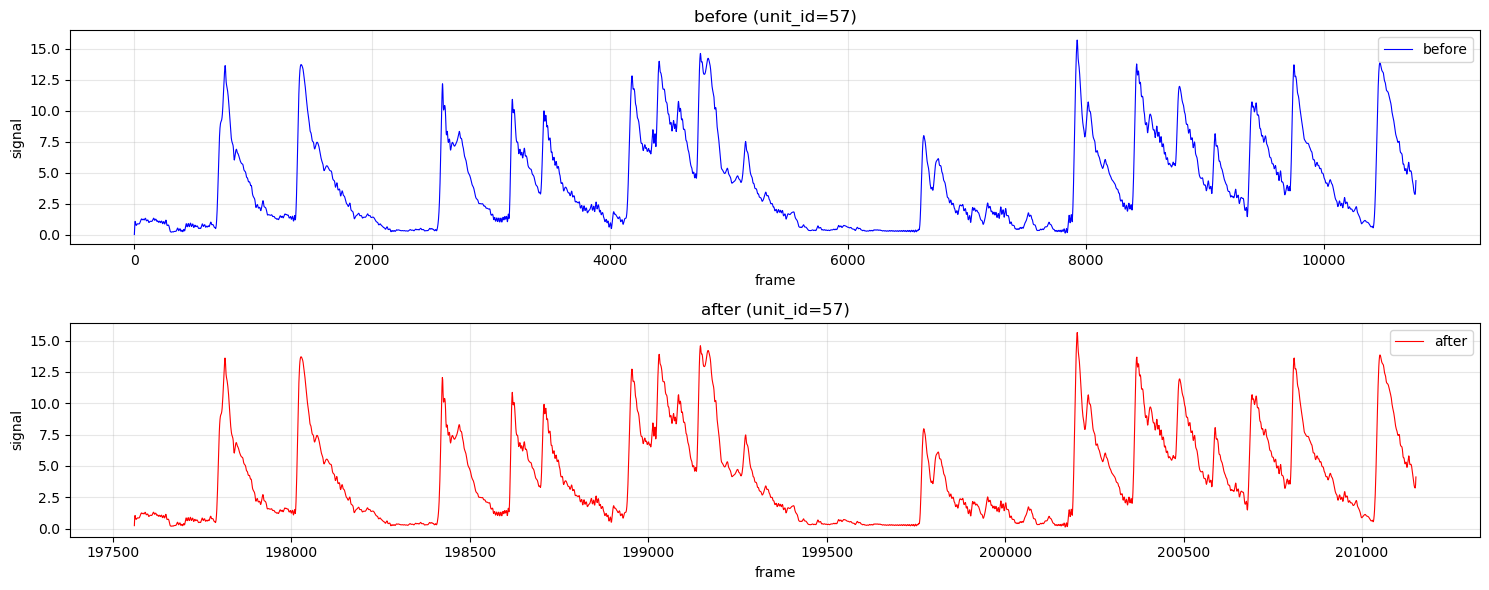

In [86]:
# 创建画布和子图
plt.figure(figsize=(15, 6))

# 绘制下采样前的数据
selected = df_signal_TST_before['unit_id'].dropna().sample(n=1).iloc[0]
plt.subplot(2, 1, 1)
before_data = df_signal_TST_before[df_signal_TST_before['unit_id'] == selected]
plt.plot(before_data['t'], before_data['value'], 'b-', linewidth=0.8, label='before')
plt.title(f'before (unit_id={selected})')
plt.xlabel('frame')
plt.ylabel('signal')

plt.grid(alpha=0.3)
plt.legend()

# 绘制下采样后的数据
plt.subplot(2, 1, 2)
after_data = df_signal_TST[df_signal_TST['unit_id'] == selected]
plt.plot(after_data.index, after_data['value'], 'r-', linewidth=0.8, label='after')
plt.title(f'after (unit_id={selected})')
plt.xlabel('frame')
plt.ylabel('signal')
plt.grid(alpha=0.3)
plt.legend()

# 调整布局并显示
plt.tight_layout()
plt.show()

In [87]:
# 6. 标准化 C：按 id 分组
df_TST = pd.merge(df_raw_TST, df_signal_TST, on=['unit_id', 't'], suffixes=('_YrA', '_C'))
df_OFT = pd.merge(df_raw_OFT, df_signal_OFT, on=['unit_id', 't'], suffixes=('_YrA', '_C'))

df_TST['residual'] = df_TST['value_YrA'] - df_TST['value_C']
df_TST['value_z'] = df_TST['value_C'] / df_TST.groupby('unit_id')['residual'].transform('std')

df_OFT['residual'] = df_OFT['value_YrA'] - df_OFT['value_C']
df_OFT['value_z'] = df_OFT['value_C'] / df_OFT.groupby('unit_id')['residual'].transform('std')

# 行列转换
resized_df_signal_TST = df_TST.pivot(index='t', columns='unit_id', values='value_z').reset_index(drop=True)  # 行=时间，列=id
resized_df_signal_OFT = df_OFT.pivot(index='t', columns='unit_id', values='value_z').reset_index(drop=True)  # 行=时间，列=id

# 对TST和OFT的每一列进行z-score标准化
resized_df_signal_TST = resized_df_signal_TST.apply(zscore, axis=0)
resized_df_signal_OFT = resized_df_signal_OFT.apply(zscore, axis=0)



In [88]:
df_TST.groupby('unit_id').size().min()

3592

In [89]:
df_signal_aligned

In [90]:
# Step 7: 根据df_signal_aligned['OFT_Unit_ID']和df_signal_aligned['TST_Unit_ID']
# 找到df_raw_TST，df_signal_TST，df_raw_OFT，df_signal_OFT中对应序号的细胞
# 将对应序号的TST和OFT细胞分别按照5帧划分，不足5帧的舍弃，同时判断每个5帧内是否有峰值并且峰值大于2.5
# 将检测到的cell_TST和cell_OFT的频率和最大峰值保存到df_signal_aligned中
if df_signal_aligned is None:
    print("No aligned data available for test1.")
else:
    df_signal_aligned['TST_freq'] = 0
    df_signal_aligned['OFT_freq'] = 0
    df_signal_aligned['TST_max_peak'] = 0
    df_signal_aligned['OFT_max_peak'] = 0

    for i in range(len(df_signal_aligned)):
        TST_Unit_ID = df_signal_aligned['TST_Unit_ID'][i]
        OFT_Unit_ID = df_signal_aligned['OFT_Unit_ID'][i]
        cell_TST = resized_df_signal_TST[TST_Unit_ID]
        cell_OFT = resized_df_signal_OFT[OFT_Unit_ID]
        # 对cell_TST和cell_OFT进行峰值检测
        peaks_TST, properties_TST = find_peaks(
        cell_TST,
        height=2,  # 峰值最小高度，根据数据特征调整  TO DO 测试1.5～3.0
        # distance=1,  # 峰值间最小距离（单位：数据点）
        # prominence=0.5  # 峰值突出度，用于过滤小波动
        )
        peaks_OFT, properties_OFT = find_peaks(
        cell_OFT,
        height=2,  # 峰值最小高度，根据数据特征调整 TO DO 测试1.5～3.0
        # distance=1,  # 峰值间最小距离（单位：数据点）
        # prominence=0.5  # 峰值突出度，用于过滤小波动
        )

        # 输出结果
        # print(f'检测到{len(peaks_TST)}个峰值')
        # print('峰值索引位置:', peaks_TST)
        # print('峰值高度:', properties_TST['peak_heights'])

        # # 可视化结果
        # plt.figure(figsize=(20, 3))
        # plt.plot(cell_TST, label='original')
        # plt.plot(peaks_TST, cell_TST[peaks_TST], 'ro', label='peak')
        # plt.axhline(y=2, color='gray', linestyle='--', label='threshold=1.5')

        # plt.xlabel('frame')
        # plt.ylabel('value_z')
        # plt.legend()
        # plt.title('cell_TST peak detection')
        # plt.show()
        # plt.close()

        # cell_TST的频率
        freq_TST = len(peaks_TST) / 6
        # cell_OFT的频率
        freq_OFT = len(peaks_OFT) / 5
        # cell_TST的最大峰值
        max_peak_TST = max(properties_TST['peak_heights'])
        # cell_OFT的最大峰值
        max_peak_OFT = max(properties_OFT['peak_heights'])


        # 检测到的cell_TST和cell_OFT的频率和最大峰值保存到df_signal_aligned中并输出
        df_signal_aligned['TST_freq'][i] = freq_TST
        df_signal_aligned['OFT_freq'][i] = freq_OFT
        df_signal_aligned['TST_max_peak'][i] = max_peak_TST
        df_signal_aligned['OFT_max_peak'][i] = max_peak_OFT
        # print(f'ID = {TST_Unit_ID} cell_TST 的频率为{freq_TST}')
        # print(f'ID = {TST_Unit_ID} cell_TST 的最大峰值为{max_peak_TST}')
        # print(f'ID = {OFT_Unit_ID} cell_OFT 的频率为{freq_OFT}')
        # print(f'ID = {OFT_Unit_ID} cell_OFT 的最大峰值为{max_peak_OFT}')

    # 保存df_signal_aligned的OFT_Unit_ID,TST_Unit_ID,TST_freq,OFT_freq,TST_max_peak和OFT_max_peak
    df_signal_aligned_csv = df_signal_aligned[['OFT_Unit_ID','TST_Unit_ID','TST_freq','OFT_freq','TST_max_peak','OFT_max_peak']]
    # df_signal_aligned_csv.to_csv(savepath1, index=False)



No aligned data available for test1.


In [91]:
# 统计TST的细胞数量，OFT的细胞数量，排除df_signal_aligned中TST_Unit_ID和OFT_Unit_ID的细胞数量
df_signal = {}
df_signal['TST_cell_total'] = len(df_TST['unit_id'].unique().tolist())
if test != 'test1' and df_signal_aligned is not None:
    df_signal['OFT_cell_total'] = len(df_OFT['unit_id'].unique().tolist())
    df_signal['TST_cell_only'] = len(df_TST['unit_id'].unique().tolist()) - len(df_signal_aligned_csv['TST_Unit_ID'].unique().tolist())
    df_signal['OFT_cell_only'] = len(df_OFT['unit_id'].unique().tolist()) - len(df_signal_aligned_csv['OFT_Unit_ID'].unique().tolist())
    df_signal['TST_cell_aligned'] = len(df_signal_aligned_csv['TST_Unit_ID'].unique().tolist())
    df_signal['OFT_cell_aligned'] = len(df_signal_aligned_csv['OFT_Unit_ID'].unique().tolist())
    df_signal = pd.DataFrame(df_signal, index=[0])
# df_signal.to_csv(savepath2, index=False)

In [92]:
# 根据TST_Unit_ID按序选择列并添加前缀  
# 获取目标列名列表（保持df_signal_aligned中的顺序)  
if test != 'test1' and df_signal_aligned is not None:
    target_columns_TST = df_signal_aligned['TST_Unit_ID'].tolist() 
    target_columns_OFT = df_signal_aligned['OFT_Unit_ID'].tolist() 

    # 根据列名列表选择数据并添加前缀  
    aligned_table_TST = resized_df_signal_TST[target_columns_TST].copy()  
    aligned_table_TST.columns = [f'TST_{col}' for col in aligned_table_TST.columns]  
    aligned_table_OFT = resized_df_signal_OFT[target_columns_OFT].copy()  
    aligned_table_OFT.columns = [f'OFT_{col}' for col in aligned_table_OFT.columns]  
    # 合并
    # aligned_table = pd.concat([aligned_table_TST, aligned_table_OFT], axis=1)

In [93]:
# 从resized_df_signal_TST中提取未对齐的TST_Unit_ID
# 从resized_df_signal_OFT中提取未对齐的OFT_Unit_ID
if test == 'test1' or df_signal_aligned is None:
    not_aligned_table_TST = resized_df_signal_TST.copy()
    not_aligned_table_TST.columns = [f'TST_{col}' for col in not_aligned_table_TST.columns]
else:
    not_aligned_id_TST = set(resized_df_signal_TST.columns) - set(df_signal_aligned['TST_Unit_ID'].unique())
    not_aligned_id_OFT = set(resized_df_signal_OFT.columns) - set(df_signal_aligned['OFT_Unit_ID'].unique())
    not_aligned_table_TST = resized_df_signal_TST[list(not_aligned_id_TST)].copy()
    not_aligned_table_TST.columns = [f'TST_{col}' for col in not_aligned_table_TST.columns]
    not_aligned_table_OFT = resized_df_signal_OFT[list(not_aligned_id_OFT)].copy()
    not_aligned_table_OFT.columns = [f'OFT_{col}' for col in not_aligned_table_OFT.columns]


In [94]:
outpath_test = path_signal_TST + "/preview_df.csv"

# ------------------------------------------------------------
# Save-only copies with two header rows:
# row 1 = final TST/OFT trace ID; row 2 = original unit_id.
# Internal DataFrames remain unchanged for later analysis.
# ------------------------------------------------------------
not_aligned_table_TST_save = add_trace_id_header(not_aligned_table_TST, 'TST')
resized_df_signal_TST_save = add_trace_id_header(resized_df_signal_TST, 'TST')

if test != 'test1' and df_signal_aligned is not None:
    aligned_table_TST_save = add_trace_id_header(aligned_table_TST, 'TST')
    aligned_table_OFT_save = add_trace_id_header(aligned_table_OFT, 'OFT')
    not_aligned_table_OFT_save = add_trace_id_header(not_aligned_table_OFT, 'OFT')
    resized_df_signal_OFT_save = add_trace_id_header(resized_df_signal_OFT, 'OFT')

match test:
    case 'test1':
        not_aligned_table_TST_save.to_csv(outpath_test, index=True)
    case 'test2':
        if df_signal_aligned is not None:
            aligned_table_TST_save.to_csv(outpath1, index=False)
            if path_signal_OFT != path_signal_TST:
                print(f'Outputing OFT aligned and not aligned tables to {outpath2} and {outpath4}')
                not_aligned_table_OFT_save.to_csv(outpath4, index=False)
                aligned_table_OFT_save.to_csv(outpath2, index=False)
                if resized_df_signal_OFT is not None:
                    resized_df_signal_OFT_save.to_csv(outpath6, index=True)
        not_aligned_table_TST_save.to_csv(outpath_test, index=True)
        if resized_df_signal_TST is not None:
            resized_df_signal_TST_save.to_csv(outpath5, index=True)


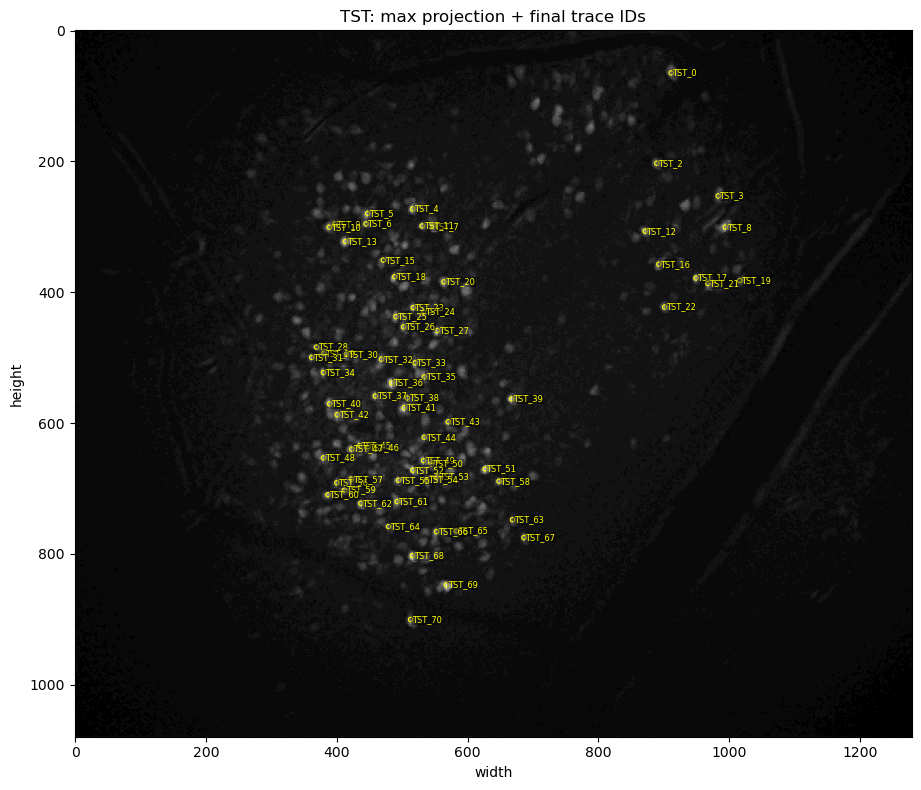

Saved spatial trace-ID map: E:\minian-videos\20260804\5831\video\20260804.110013.821\save_result\TST_OFT_ID_max_proj.png


In [95]:
# ============================================================
# Spatial trace-ID map: original position -> unit_id -> TST/OFT ID
# ============================================================

# Use the final trace columns after all existing filtering/downsampling steps.
final_unit_ids_TST = list(resized_df_signal_TST.columns)
final_unit_ids_OFT = list(resized_df_signal_OFT.columns)

# Prefer the existing signal-save folder when defined; otherwise save beside TST CSVs.
if 'path_signal_save' in globals() and path_signal_save:
    spatial_map_dir = path_signal_save
else:
    spatial_map_dir = path_signal_TST
os.makedirs(spatial_map_dir, exist_ok=True)
spatial_map_path = os.path.join(spatial_map_dir, 'TST_OFT_ID_max_proj.png')

if test == 'test1':
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    spatial_centroids_TST = plot_trace_ids_on_max_proj(
        ax,
        df_max_proj_TST,
        df_A_center_TST,
        final_unit_ids_TST,
        'TST',
        'TST: max projection + final trace IDs',
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    spatial_centroids_TST = plot_trace_ids_on_max_proj(
        axes[0],
        df_max_proj_TST,
        df_A_center_TST,
        final_unit_ids_TST,
        'TST',
        'TST: max projection + final trace IDs',
    )
    spatial_centroids_OFT = plot_trace_ids_on_max_proj(
        axes[1],
        df_max_proj_OFT,
        df_A_center_OFT,
        final_unit_ids_OFT,
        'OFT',
        'OFT: max projection + final trace IDs',
    )

plt.tight_layout()
plt.savefig(spatial_map_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved spatial trace-ID map:', spatial_map_path)


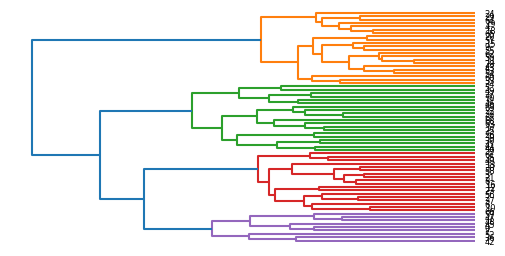

In [96]:
minmax_scaler = MinMaxScaler()
minmax_normalized_data = minmax_scaler.fit_transform(resized_df_signal_TST)
minmax_normalized_df = pd.DataFrame(minmax_normalized_data, columns=resized_df_signal_TST.columns)
ax = plt.figure(figsize=(6, 3))
Z = hierarchy.linkage(minmax_normalized_df.T, method='ward',metric='euclidean')
hierarchy.dendrogram(Z, labels=resized_df_signal_TST.columns,orientation='left')
heatmapfig = ax.get_figure()
plt.gca().axes.get_xaxis().set_visible(False)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().invert_yaxis()
plt.show()

In [97]:
# Step 8: 绘制热图
# 创建热图method
def heatmap_plot(data,subtitle,filepath,is_save=False):
# 创建 MinMaxScaler 对象
    minmax_scaler = MinMaxScaler()

# 对 DataFrame 进行 Min-Max 归一化
    minmax_normalized_data = minmax_scaler.fit_transform(data)

# 将结果转换回 DataFrame
    minmax_normalized_df = pd.DataFrame(minmax_normalized_data, columns=data.columns)
    minmax_normalized_df.to_csv(filepath + '_normalized.csv', index=False)

# 直接在clustermap中设置图形大小，避免重复创建figure，但不聚类
    g = sns.clustermap(minmax_normalized_df.T,
                    method='ward',
                    metric='euclidean',
                    cmap='coolwarm',
                    col_cluster=False,
                    row_cluster=False,  # 设置为False以避免行聚类
                    figsize=(10, 3), 
                    cbar_kws={'label': 'Normalized Value'})  # 添加颜色条标签

# 使用ClusterGrid对象的suptitle方法设置标题，避免覆盖问题
    g.figure.suptitle(subtitle, y=1.05)  # y参数调整标题位置，防止被裁剪  # 显示图形

# 保存为矢量图(pdf格式)
    if is_save:
        plt.savefig(filepath + '.pdf',
                    format='pdf',
                    bbox_inches='tight',  # 自动调整边界，防止元素被裁剪
                    dpi=300,
                    transparent=True)  # 虽然矢量图不需要dpi，但设置高分辨率确保兼容性
    plt.close()

# 聚类效果
    g = sns.clustermap(minmax_normalized_df.T,
                    method='ward',
                    metric='euclidean',
                    cmap='coolwarm',
                    col_cluster=False,
                    row_cluster=True,  # 开启行聚类		
                    figsize=(6, 3), 
                    cbar_kws={'label': 'Normalized Value'})

# 使用ClusterGrid对象的suptitle方法设置标题，避免覆盖问题
    g.figure.suptitle(subtitle + ' clustered', y=1.05)  # y参数调整标题位置，防止被裁剪  # 显示图形
# 保存 ClusterGrid对象 为 .csv 文件
    if is_save:
        g.data.to_csv(filepath + '_clustered.csv', index=False)
# 保存为矢量图(pdf格式)，确保完整显示所有元素
        plt.savefig(filepath + '_clustered.pdf',
                format='pdf',
                bbox_inches='tight',  # 自动调整边界，防止元素被裁剪
                dpi=300,
                transparent=True)  # 虽然矢量图不需要dpi，但设置高分辨率确保兼容性
    plt.show()
    plt.close()
#聚类颜色分类
    ax = plt.figure(figsize=(10, 6))
    Z = hierarchy.linkage(minmax_normalized_df.T, method='ward',metric='euclidean')
    hierarchy.dendrogram(Z, labels=data.columns,orientation='left')
    order = hierarchy.dendrogram(Z, labels=data.columns)['leaves']
    heatmapfig = ax.get_figure()
    plt.gca().axes.get_xaxis().set_visible(False)
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    plt.gca().invert_yaxis()
    if is_save:
        heatmapfig.savefig(filepath + '_clustered_dendrogram.pdf', dpi=100)
    plt.show()
    plt.close()
    return minmax_normalized_df,order



In [98]:
if test !='test1':
    heatmap_plot(aligned_table_TST, 'TST aligned heatmap', fig_path + '/aligned_TST_heatmap')#,True) #is_save需设置为True以保存

In [99]:
if test !='test1':
    heatmap_plot(aligned_table_OFT, 'OFT aligned heatmap', fig_path + '/aligned_OFT_heatmap')

In [100]:
resized_df_signal_TST.shape

(3592, 69)

In [101]:
path_signal_TST

'E:\\minian-videos\\20260804\\5831\\video\\20260804.110013.821\\save_result'

c:\Users\PC\miniconda3\envs\conda_global\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


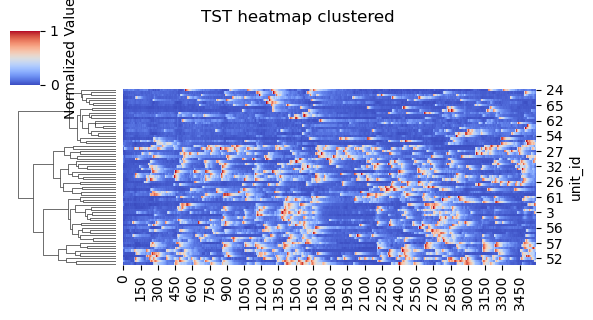

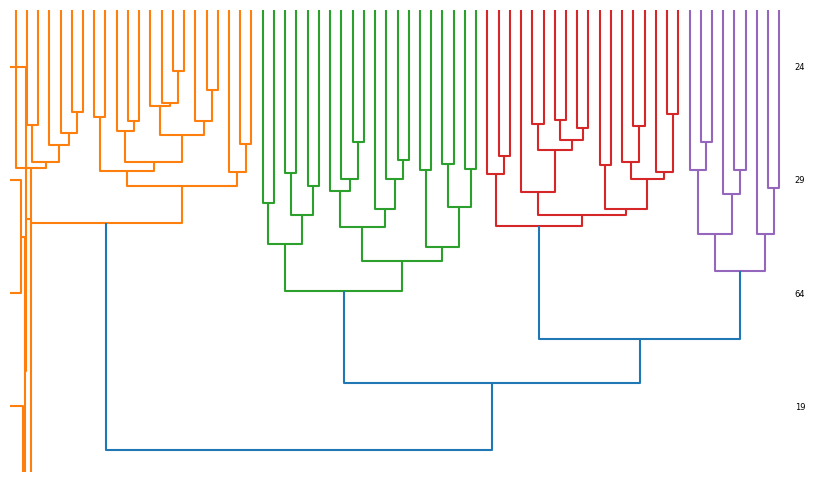

(unit_id        0         2         3         4         5         6         7   \
 0        0.005000  0.004602  0.000000  0.000000  0.031779  0.000000  0.000798   
 1        0.059570  0.021982  0.052596  0.015946  0.163377  0.009016  0.001397   
 2        0.069500  0.038149  0.111012  0.029097  0.209796  0.016735  0.002788   
 3        0.062651  0.047548  0.140512  0.038221  0.194185  0.022339  0.002952   
 4        0.051758  0.044344  0.135521  0.043102  0.155892  0.026262  0.000651   
 ...           ...       ...       ...       ...       ...       ...       ...   
 3587     0.198355  0.089618  0.511908  0.015777  0.524438  0.036307  0.219594   
 3588     0.179119  0.084108  0.491799  0.023600  0.497432  0.037265  0.215948   
 3589     0.165607  0.072524  0.500917  0.035886  0.451791  0.045867  0.213033   
 3590     0.172243  0.066965  0.544102  0.051177  0.482251  0.056099  0.210649   
 3591     0.227894  0.075438  0.586424  0.067479  0.612820  0.065856  0.208936   
 
 unit_id      

In [102]:
heatmap_plot(resized_df_signal_TST, 'TST heatmap', path_signal_TST + '/TST_heatmap',is_save=True)

In [103]:
if test !='test1':
    heatmap_plot(resized_df_signal_OFT, 'OFT heatmap', fig_path + '/OFT_heatmap')